In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Loading Dataset

In [ ]:
df = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\customer_churn_feature_engineered.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 36)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Revenue_Per_Month,Customer_Value,Service_Count,Gender_Male,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,86,3239,36.050000,107.7,3,True,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,67,2701,50.550000,141.4,1,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,86,5372,91.166667,797.2,5,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,84,5003,105.036207,2934.4,6,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,89,5340,100.726000,5081.3,6,True,...,False,True,False,True,False,False,True,False,False,False


## Loading Best Model

In [3]:
model = joblib.load(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\models\best_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


## Feature Matrix

In [5]:
X = df.drop("Churn Value", axis=1)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (7043, 35)


## Generating Churn Probablities

In [6]:
churn_probability = model.predict_proba(X)[:,1]

print(churn_probability[:10])

[0.945 0.84  0.95  0.88  0.895 0.35  0.995 0.975 0.655 0.965]


## Adding Probability Column

In [7]:
df["Churn_Probability"] = churn_probability

df[["Churn_Probability"]].head()

,Churn_Probability
0,0.945
1,0.840
2,0.950
3,0.880
4,0.895


## Creating Risk Segemnts

In [8]:
def assign_risk(prob):

    if prob >= 0.80:
        return "High Risk"
    elif prob >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

In [9]:
df["Risk_Segment"] = df["Churn_Probability"].apply(assign_risk)

df[["Churn_Probability","Risk_Segment"]].head()

,Churn_Probability,Risk_Segment
0,0.945,High Risk
1,0.840,High Risk
2,0.950,High Risk
3,0.880,High Risk
4,0.895,High Risk


In [13]:
segment_summary = df.groupby("Risk_Segment").agg({

    "Churn_Probability":"mean",
    "Monthly Charges":"mean",
    "Total Charges":"mean"

}).round(2)

segment_summary

,Churn_Probability,Monthly Charges,Total Charges
Risk_Segment,,,
High Risk,0.93,75.81,1374.72
Low Risk,0.04,61.16,2564.53
Medium Risk,0.70,69.80,2060.42


## Segmnents Counts

In [14]:
df["Risk_Segment"].value_counts()

Risk_Segment
Low Risk       5173
High Risk      1528
Medium Risk     342
Name: count, dtype: int64

## Saving Master Segmentation File

In [20]:
output_path = r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Risk_segmentation\outputs"

df.to_csv(f"{output_path}\customer_risk_segments.csv",index=False)

print("Master Segmentation File Saved")

Master Segmentation File Saved


<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Hey!\AppData\Local\Temp\ipykernel_16468\1852504720.py:3: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv(f"{output_path}\customer_risk_segments.csv",index=False)


## Creating High risk File

In [19]:
high_risk = df[df["Risk_Segment"]=="High Risk"]

high_risk.to_csv(f"{output_path}\high_risk_customers.csv",index=False)

print(high_risk.shape)

(1528, 38)


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Hey!\AppData\Local\Temp\ipykernel_16468\2312418933.py:3: SyntaxWarning: invalid escape sequence '\h'
  high_risk.to_csv(f"{output_path}\high_risk_customers.csv",index=False)


## Creating Meduim Risk File

In [23]:
medium_risk = df[df["Risk_Segment"]=="Medium Risk"]

medium_risk.to_csv(f"{output_path}\medium_risk_customers.csv",index=False)

print(medium_risk.shape)

(342, 38)


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Hey!\AppData\Local\Temp\ipykernel_16468\1345134308.py:3: SyntaxWarning: invalid escape sequence '\m'
  medium_risk.to_csv(f"{output_path}\medium_risk_customers.csv",index=False)


## Create Low Risk file

In [25]:
low_risk = df[df["Risk_Segment"]=="Low Risk"]

low_risk.to_csv(f"{output_path}\low_risk_customers.csv",index=False)

print(low_risk.shape)

(5173, 38)


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Hey!\AppData\Local\Temp\ipykernel_16468\984172471.py:3: SyntaxWarning: invalid escape sequence '\l'
  low_risk.to_csv(f"{output_path}\low_risk_customers.csv",index=False)


## Visualizations

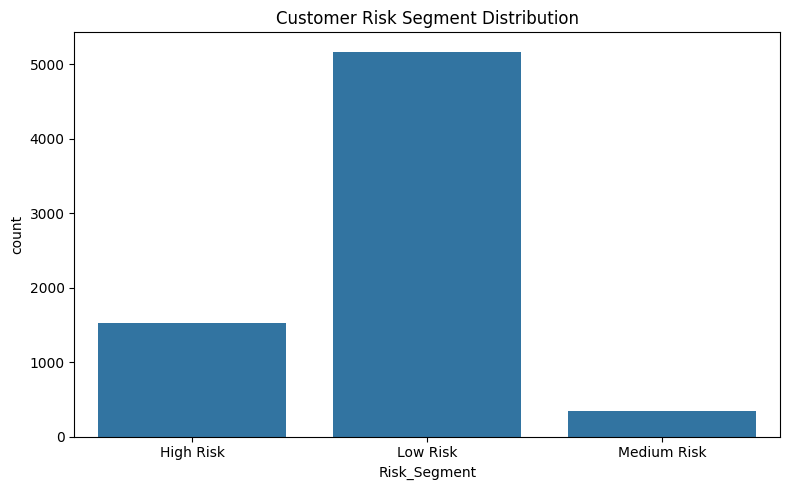

In [26]:
## Risk Segment Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Risk_Segment")

plt.title("Customer Risk Segment Distribution")
plt.tight_layout()

plt.savefig(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\risk_segmentation\visualizations\risk_segment_distribution.png")

plt.show()

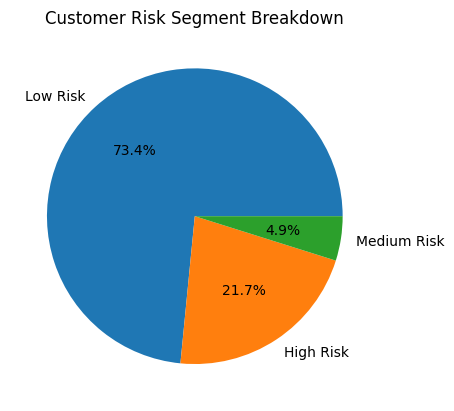

In [27]:
## Pie Chart


df["Risk_Segment"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")
plt.title("Customer Risk Segment Breakdown")

plt.savefig(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\risk_segmentation\visualizations\risk_segment_pie_chart.png")

plt.show()

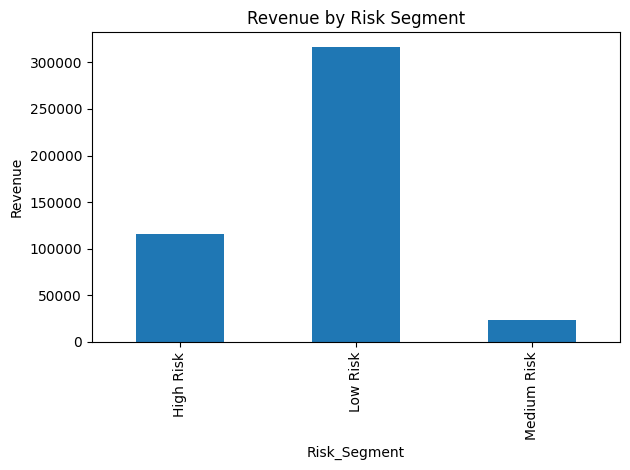

In [28]:
## Revenue By Segment

revenue = df.groupby("Risk_Segment")["Monthly Charges"].sum()

revenue.plot(kind="bar")

plt.title("Revenue by Risk Segment")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\risk_segmentation\visualizations\revenue_by_segment.png")

plt.show()

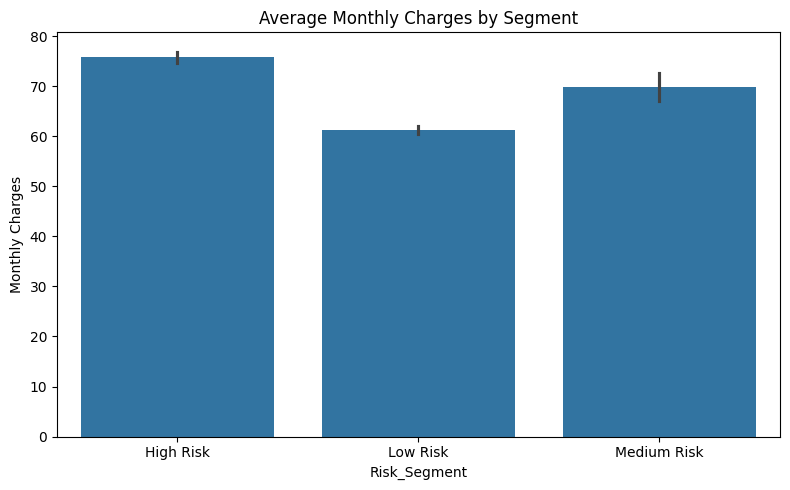

In [30]:
## Average Monthly Charges

plt.figure(figsize=(8,5))

sns.barplot(data=df,x="Risk_Segment",y="Monthly Charges")

plt.title("Average Monthly Charges by Segment")

plt.tight_layout()

plt.savefig(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\risk_segmentation\visualizations\avg_monthly_charge_segment.png")

plt.show()

In [39]:
## Actual Churn Rate

churn_rate = (df.groupby("Risk_Segment")["Churn Value"].mean()*100)

churn_rate

Risk_Segment
High Risk      99.476440
Low Risk        0.908564
Medium Risk    88.304094
Name: Churn Value, dtype: float64

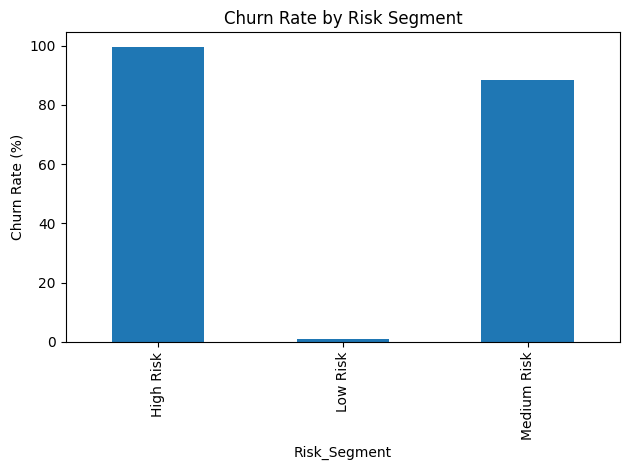

In [40]:
churn_rate.plot(kind="bar")

plt.title("Churn Rate by Risk Segment")

plt.ylabel("Churn Rate (%)")

plt.tight_layout()

plt.savefig(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\risk_segmentation\visualizations\churn_rate_by_segment.png")

plt.show()

## Retention Strategy Table

In [44]:
strategy = pd.DataFrame({
    
    "Risk Segment":      ["High Risk","Medium Risk","Low Risk"],

    "Recommended Action":["Immediate Retention Call","Offer Discount / Promotion",
                          "Regular Monitoring"]})

strategy

,Risk Segment,Recommended Action
0,High Risk,Immediate Retention Call
1,Medium Risk,Offer Discount / Promotion
2,Low Risk,Regular Monitoring


In [45]:
strategy.to_csv(f"{output_path}\ retention_strategy.csv",index=False)

print("Retention Strategy Saved")

Retention Strategy Saved


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Hey!\AppData\Local\Temp\ipykernel_16468\2953716641.py:1: SyntaxWarning: invalid escape sequence '\ '
  strategy.to_csv(f"{output_path}\ retention_strategy.csv",index=False)
